# Computational Statistics & Data Analysis - Exercise Sheet 6

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sym
import math
import time
import datetime

## Task 1

Two samples $X_A$ and $X_B$ and we want to test if their means are equal with significance level of $\alpha=0.01$:

$H_0$: means of both distributions are equal

$H_1$: the means of both distributions differ significantly


To do that we have to consider the following random variable:
$Z := (\bar X_A - \bar X_B)/(\hat \sigma_{\bar X_A - \bar X_B}) \sim t_{N_A+N_B-2}$ 

with $\hat \sigma_{\bar X_A - \bar X_B}^2= ((N_A-1)s_{X_A}^2+(N_B-1)s_{X_B}^2)(\frac{1}{N_A}+\frac{1}{N_B})/(N_A+N_B-2)$

In [19]:
X_A = np.array([5.1,4.95,5.15,5.04,4.89,5.05,5.0,4.9,4.96,5.06,5.04,5.12])
X_B = np.array([4.9,4.96,4.89,5.02,5.03,5.07,4.95,4.98,5.05,5.08])

N_A = len(X_A)
N_B = len(X_B)

X_A_mean=X_A.mean()
X_B_mean=X_B.mean()

s_X_A = X_A.std(ddof=1)
s_X_B = X_B.std(ddof=1)

sigma_XA_XB=np.sqrt(((N_A-1)*s_X_A**2+(N_B-1)*s_X_B**2)*(1/N_A+1/N_B)/(N_A+N_B-2))

Z=(X_A_mean-X_B_mean)/sigma_XA_XB
print(f"Z={Z}")

Z=0.8717127863184327


Calculate both-sided p-value:

In [22]:
p=2*(1-sp.stats.t.cdf(abs(Z),df=N_A+N_B-2))
p

0.393709488723901

Since $p\approx 0.29>\alpha$ we fail to reject the null hypothesis!

## Task 2

$H_0$: sample variance is consistant with given variance

$H_1$: sample variance is not consistant with given variance

We want to compare the dispersion of our measurement with the given precision of 0.2K.

Therefore we define $\tilde Z:=s_X^2/\sigma^2$. We don't know how this is distributed, but we know:

$Z:=(n-1)s_X^2/\sigma^2\sim \chi^2(n-1)$

In [24]:
X =np.array([10.2,10.4,9.8,10.5,9.9,9.8,10.3,10.1,10.3,9.9])
sigma=0.2
n=len(X)

sample_var = X.var(ddof=1)
Z=(n-1)*sample_var/sigma**2

print(f"Z={Z}")

Z=14.899999999999983


Calculate p-value: Is sample variance to large?

In [33]:
p=1-sp.stats.chi2.cdf(Z,df=n-1)
print(f"p={p}")

p=0.09371968438842493


Since $p>\alpha$ we fail to reject the null hypothesis and we believe it to be true!

Now we also know that the true mean is given by $\mu=10.1K$.

Therefore the sample variance is given by $s_x^2=(\sum_i(X_i-\mu)^2)/n$, and Z becomes:

$Z= ns_X^2/\sigma^2\sim \chi^2(n)$

In [35]:
mu=10.1

sample_var = np.sum((X-mu)**2)/n
Z=n*sample_var/sigma**2

print(f"Z={Z}")

Z=14.999999999999986


Calculate p-value: Is sample variance to large?

In [37]:
p=1-sp.stats.chi2.cdf(Z,df=n)
print(f"p={p}")

p=0.13206185628772105


Since $p>\alpha$ we fail to reject the null hypothesis and we believe it to be true!

## Task 3

In [42]:
df = pd.read_excel("ex6task3.xlsx")
t = df["time"].to_numpy()
x = df["displacement"].to_numpy()

In [53]:
from scipy.integrate import odeint
def damped_harmonic_osc(y, t, c, k):
    m = 1.0
    x, v = y
    dydt = [v,-(c/m)*v- (k/m)*x]
    return dydt

# Time points
t = np.linspace(0, 15, 151)
# Initial conditions
x0 = 1.0 # initial displacement
v0 = 0.0 # initial velocity
y0 = [x0, v0]
# Solve ODE

def simulation(c,k):
    simulation = odeint(damped_harmonic_osc, y0, t, args=(c, k))[:, 0]
    return simulation

def MSE(simul,data):
    return np.sum((data-simul)**2)/len(data)

In [122]:
def MH_algorithm(theta0, max_iterations):
    theta=np.zeros((2,max_iterations+1))
    theta[0][0],theta[1][0]=theta0
    pXtheta=np.exp(-MSE(simulation(*theta0),x))
    
    for i in range(max_iterations):
        new_c=theta[0][i]+np.random.normal(0,0.05)
        new_k=theta[1][i]+np.random.normal(0,0.05)
        
        if new_c<0 or new_c>5 or new_k<0 or new_k>10:
            theta[0][i+1],theta[1][i+1]=theta[0][i],theta[1][i]
            
        else:
            pXnewtheta=np.exp(-MSE(simulation(new_c,new_k),x))
            alpha=np.minimum(1,pXnewtheta/pXtheta)
            
            if np.random.random()<alpha:
                theta[0][i+1],theta[1][i+1]=new_c,new_k
                pXtheta=pXnewtheta
            else:
                theta[0][i+1],theta[1][i+1]=theta[0][i],theta[1][i]
            
    return theta[0][10000::5],theta[1][10000::5]

In [163]:
def MH_algorithm(theta0, max_iterations):

    theta = np.zeros((2, max_iterations+1))
    theta[0][0], theta[1][0] = theta0

    current_logp = -MSE(simulation(*theta0), x)

    for i in range(max_iterations):

        new_c = theta[0][i] + np.random.normal(0, np.sqrt(0.05))
        new_k = theta[1][i] + np.random.normal(0, np.sqrt(0.05))

        # prior bounds
        if new_c < 0 or new_c > 5 or new_k < 0 or new_k > 10:
            theta[:, i+1] = theta[:, i]
            continue

        new_logp = -MSE(simulation(new_c, new_k), x)

        log_alpha = new_logp - current_logp

        if np.log(np.random.rand()) < log_alpha:
            theta[0][i+1], theta[1][i+1] = new_c, new_k
            current_logp = new_logp
        else:
            theta[:, i+1] = theta[:, i]

    burn_in = 20000
    thin = 5

    return theta[0][burn_in::thin], theta[1][burn_in::thin]

In [164]:
c,k=MH_algorithm([1,1],100000)

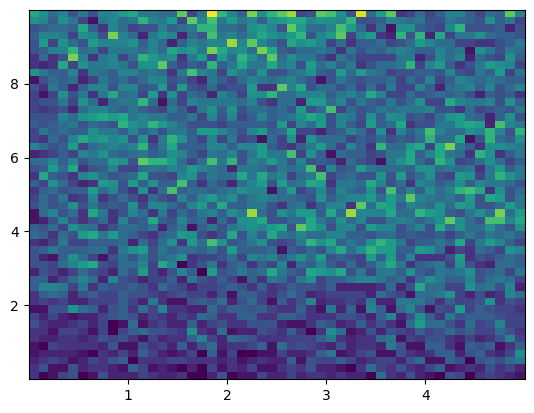

In [165]:
plt.hist2d(c,k,bins=(50,50),density=True)
plt.show()

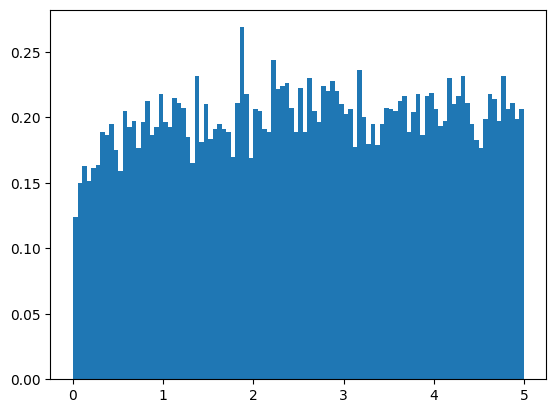

In [166]:
plt.hist(c,100,density=True)
plt.show()

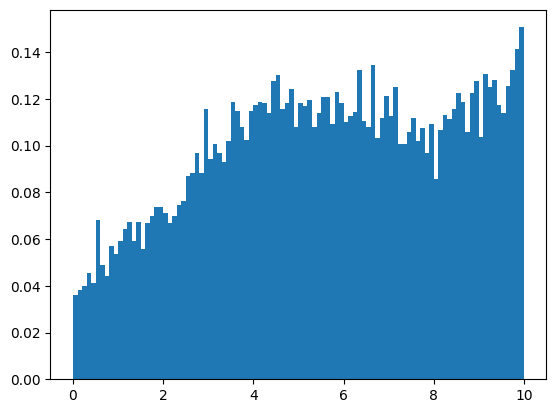

In [167]:
plt.hist(k,100,density=True)
plt.show()

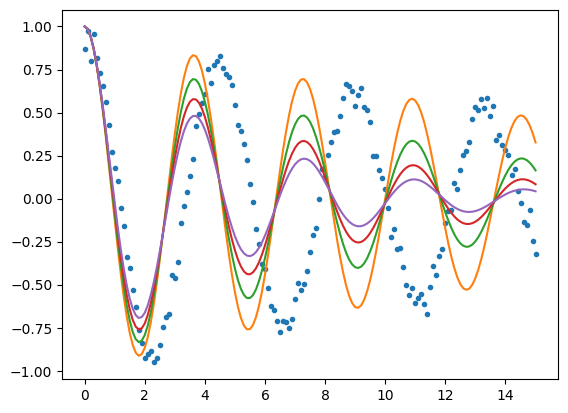

In [152]:
c,k=2,3

plt.plot(t,x,".")
#for k in range(1,10):
for c in range(1,5):
    plt.plot(t,simulation(c/10,k))
plt.show()